In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from abstract_values.behavior.data import Subject, get_all_subjects, get_all_subject_ids, get_all_behavioral_data

In [17]:
df = get_all_behavioral_data()
df = df[df['event_type'] == 'feedback']

df['response'] = df['response'].astype(float)

In [18]:
# Count non-responses per subject (normalized)
non_responses = df[df['response'].isna()].groupby('subject').size() / df.groupby('subject').size()
print("Non-responses per subject:")
print(non_responses)

non_responses.agg(['mean', 'std'])

Non-responses per subject:
subject
1     0.046196
2     0.021739
3     0.013587
4     0.016304
5     0.046196
7     0.016304
8     0.016304
9     0.027174
10    0.046196
11    0.013587
12    0.043478
13    0.013587
14    0.032609
15    0.016304
16    0.016304
dtype: float64


mean    0.025725
std     0.013426
dtype: float64

In [19]:
df.groupby(['subject', 'mapping']).size()

subject  mapping    
1        cdf            184
         inverse_cdf    184
2        cdf            184
         inverse_cdf    184
3        cdf            184
         inverse_cdf    184
4        cdf            184
         inverse_cdf    184
5        cdf            184
         inverse_cdf    184
7        cdf            184
         inverse_cdf    184
8        cdf            184
9        cdf            184
         inverse_cdf    184
10       cdf            184
         inverse_cdf    184
11       cdf            184
         inverse_cdf    184
12       cdf            184
         inverse_cdf    184
13       cdf            184
         inverse_cdf    184
14       cdf            184
15       inverse_cdf    184
16       cdf            184
dtype: int64

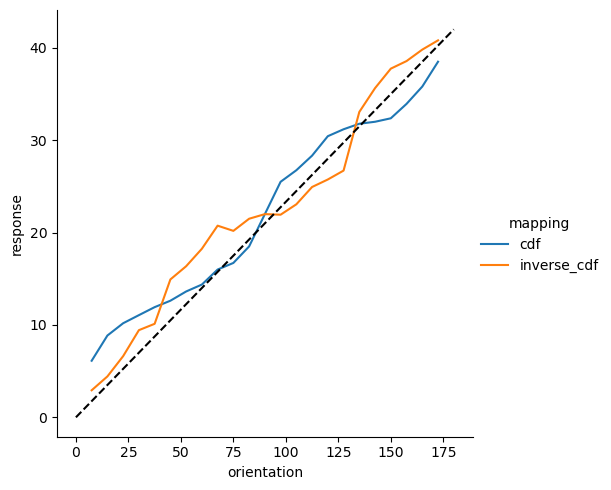

In [20]:
tmp = df.xs(5, level='subject', drop_level=False).groupby(['subject', 'mapping', 'orientation'])['response'].mean()

g = sns.relplot(data=tmp.reset_index(), x='orientation', y='response', hue='mapping', kind='line')
plt.plot([0, 180], [0, 42], 'k--')

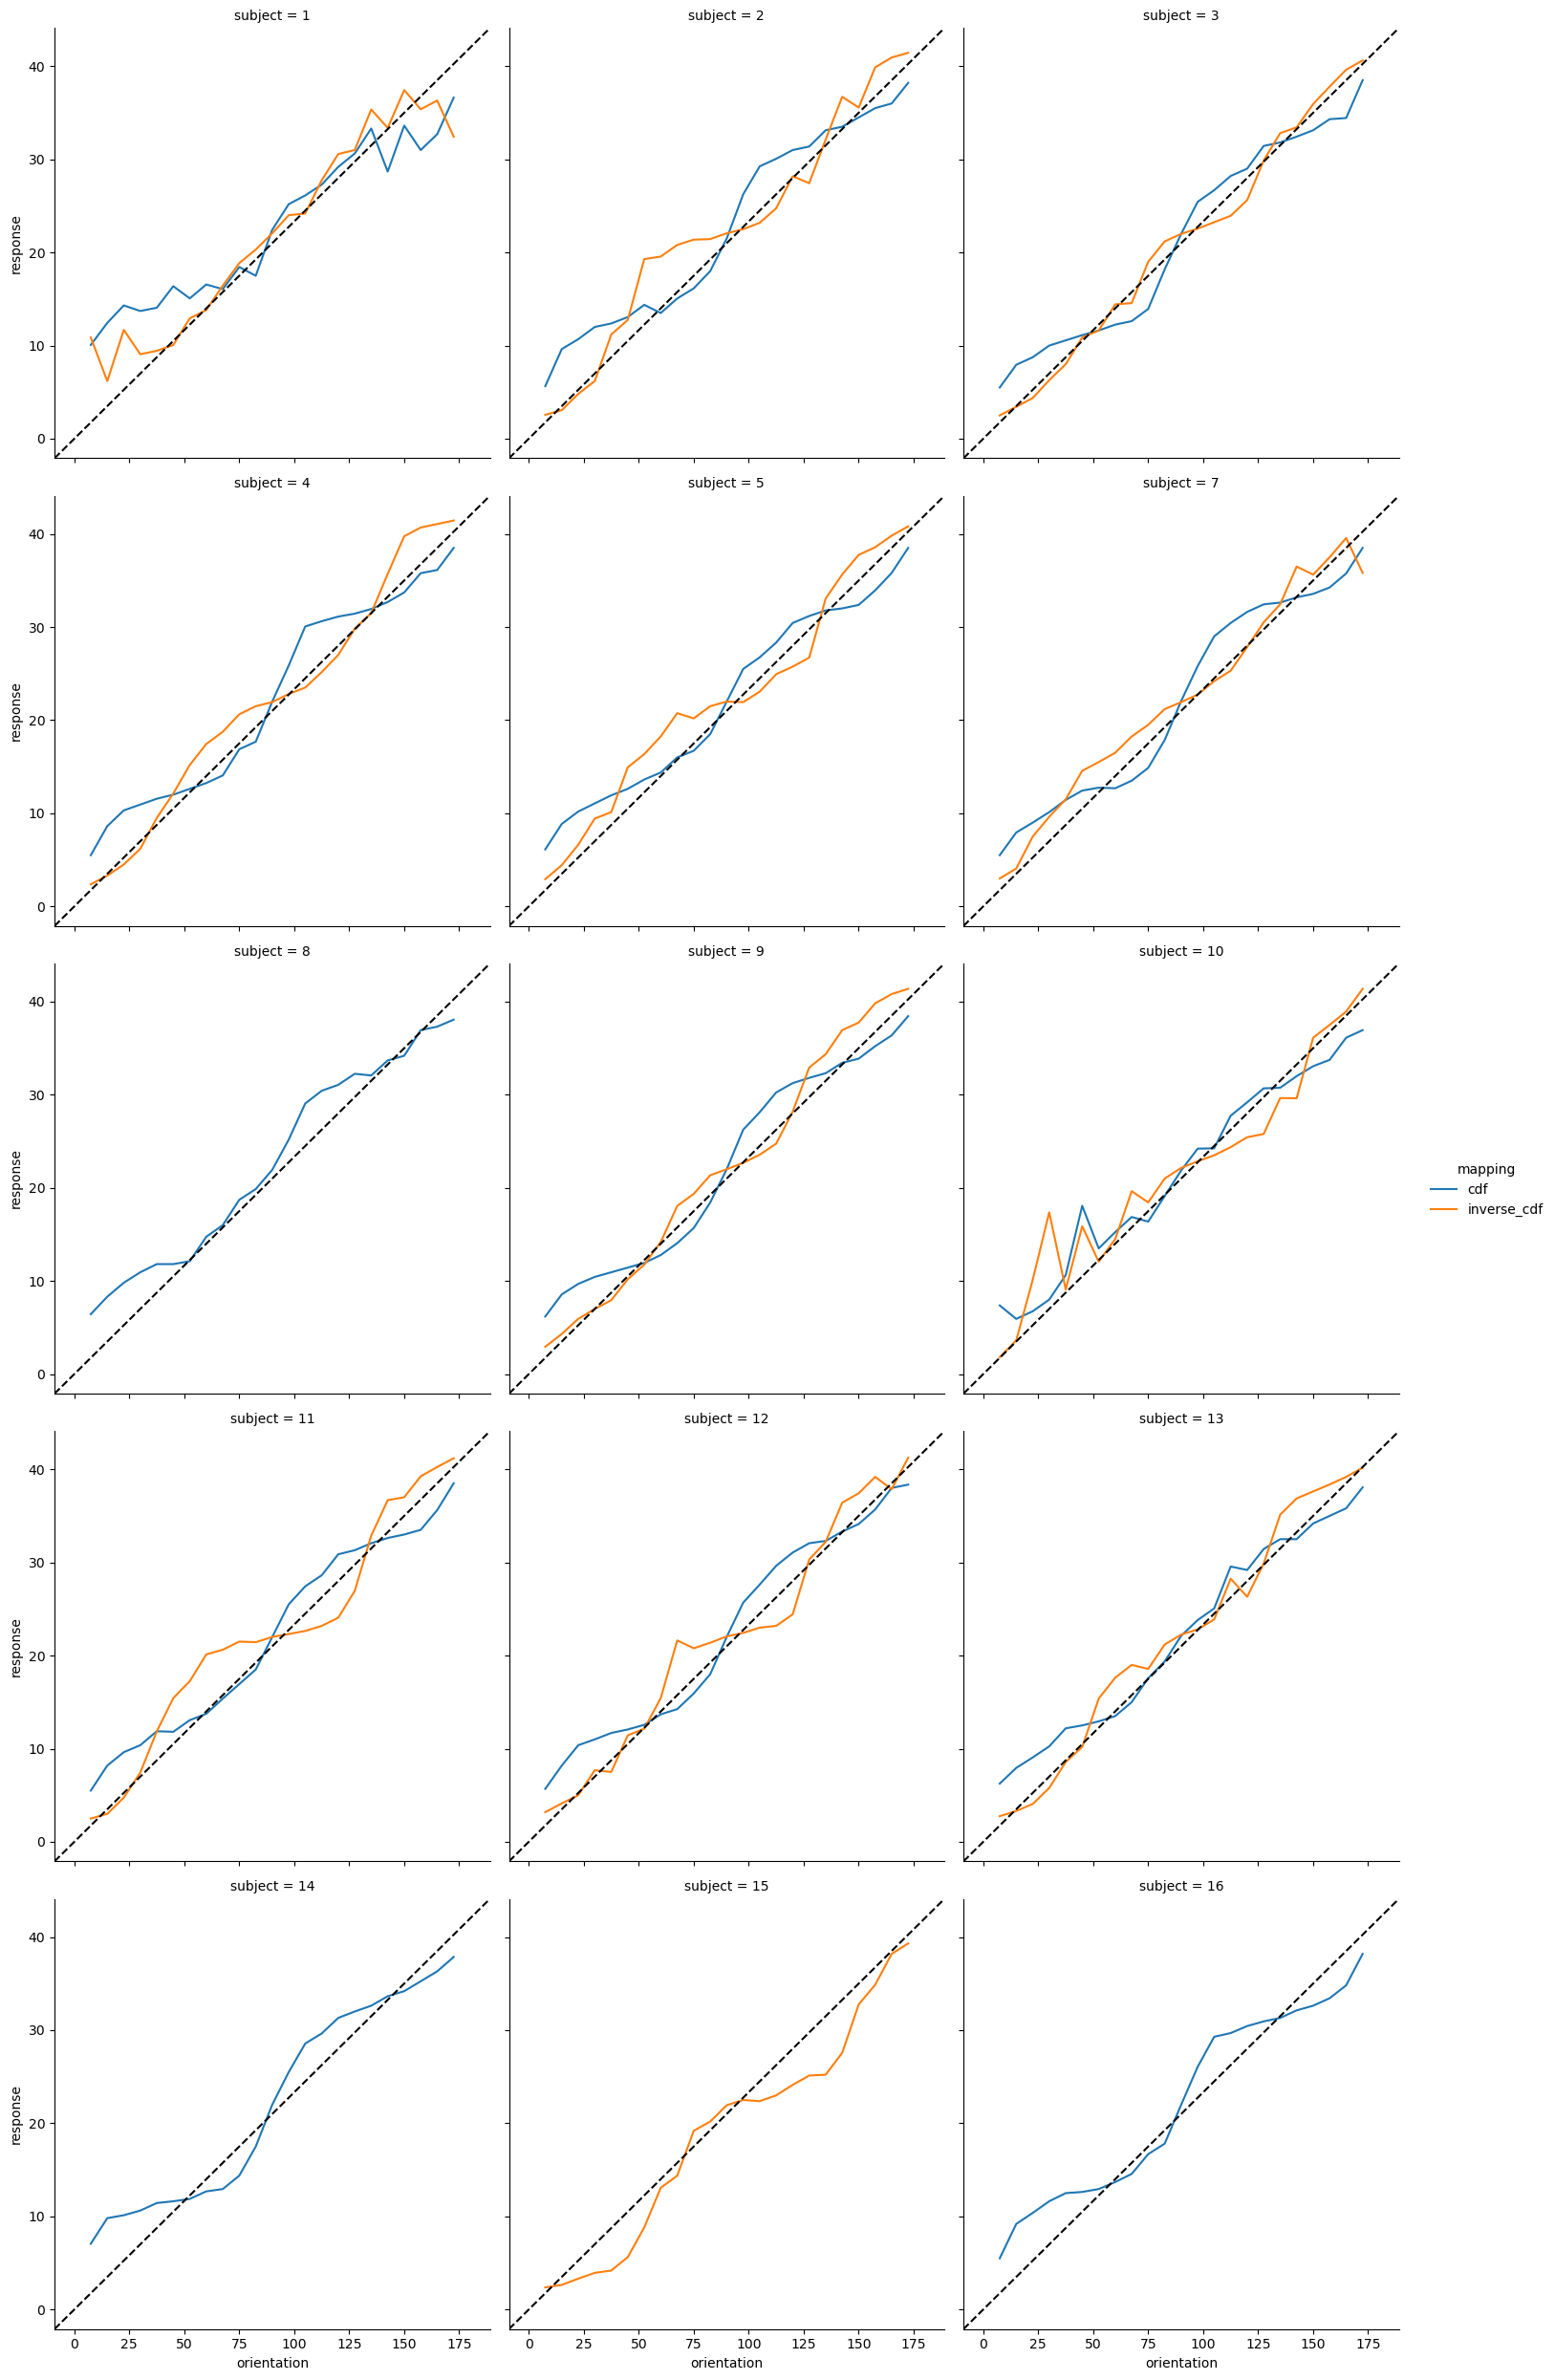

In [21]:
tmp = df.groupby(['subject', 'mapping', 'orientation'])['response'].mean()

g = sns.relplot(data=tmp.reset_index(), x='orientation', y='response', hue='mapping', kind='line',
                col='subject', col_wrap=3)

g.map(plt.axline, xy1=(0, 0), xy2=(180, 42), ls='--', c='k')

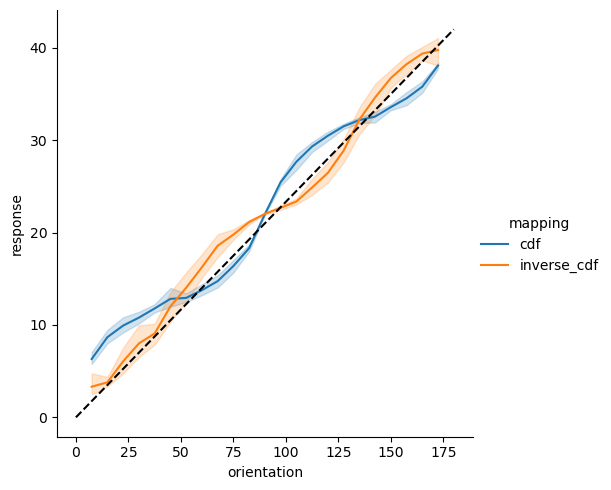

In [22]:
tmp = df.groupby(['subject', 'mapping', 'orientation'])['response'].mean()

g = sns.relplot(data=tmp.reset_index(), x='orientation', y='response', hue='mapping', kind='line')
plt.plot([0, 180], [0, 42], 'k--')

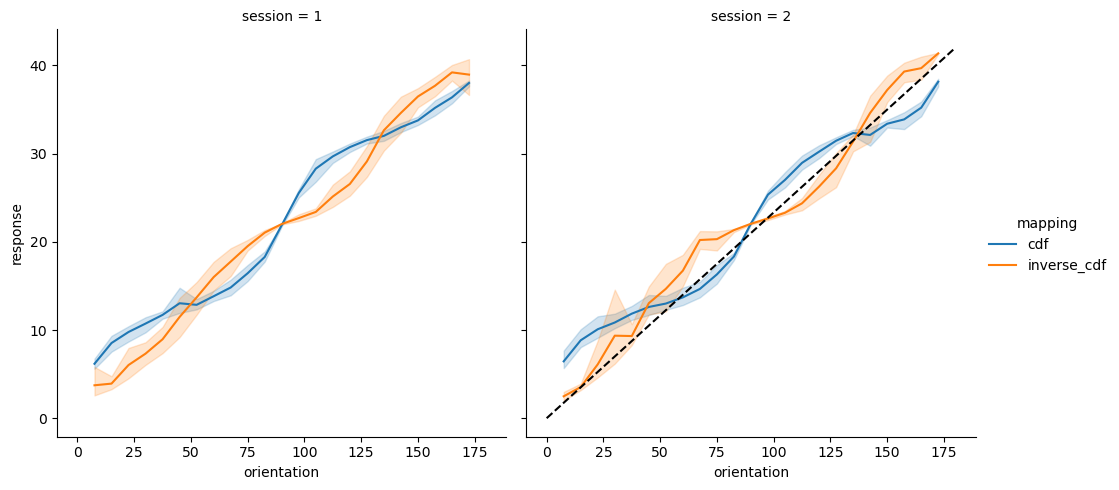

In [23]:
tmp = df.groupby(['subject', 'mapping', 'orientation', 'session'])['response'].mean()

g = sns.relplot(data=tmp.reset_index(), x='orientation', y='response', hue='mapping', kind='line', col='session')
plt.plot([0, 180], [0, 42], 'k--')

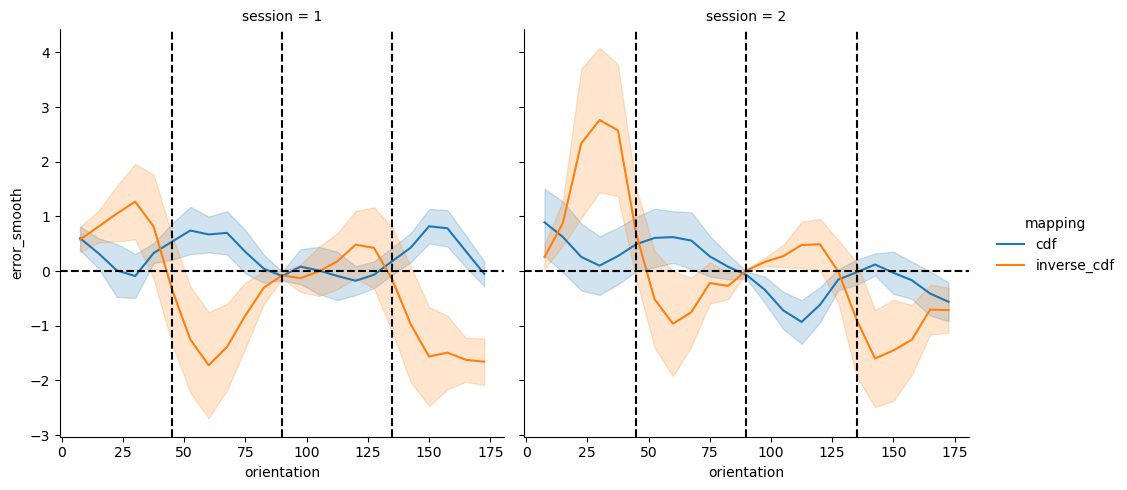

In [ ]:
work = df.reset_index().copy()
work['error'] = work['response'] - work['value']

tmp = (
    work.groupby(['subject', 'mapping', 'orientation', 'session'], as_index=False)['error']
        .mean()
        .sort_values(['subject', 'mapping', 'orientation', 'session'])
)

tmp['error_smooth'] = (
    tmp.groupby(['subject', 'mapping'])['error']
       .transform(lambda s: s.rolling(3, center=True, min_periods=1).mean())
)

g = sns.relplot(data=tmp, x='orientation', y='error_smooth', hue='mapping', kind='line', errorbar='se', col='session')
g.map(plt.axhline, y=0, color='k', linestyle='--')
for ori in [45, 90, 135]:
    g.map(plt.axvline, x=ori, color='k', linestyle='--')

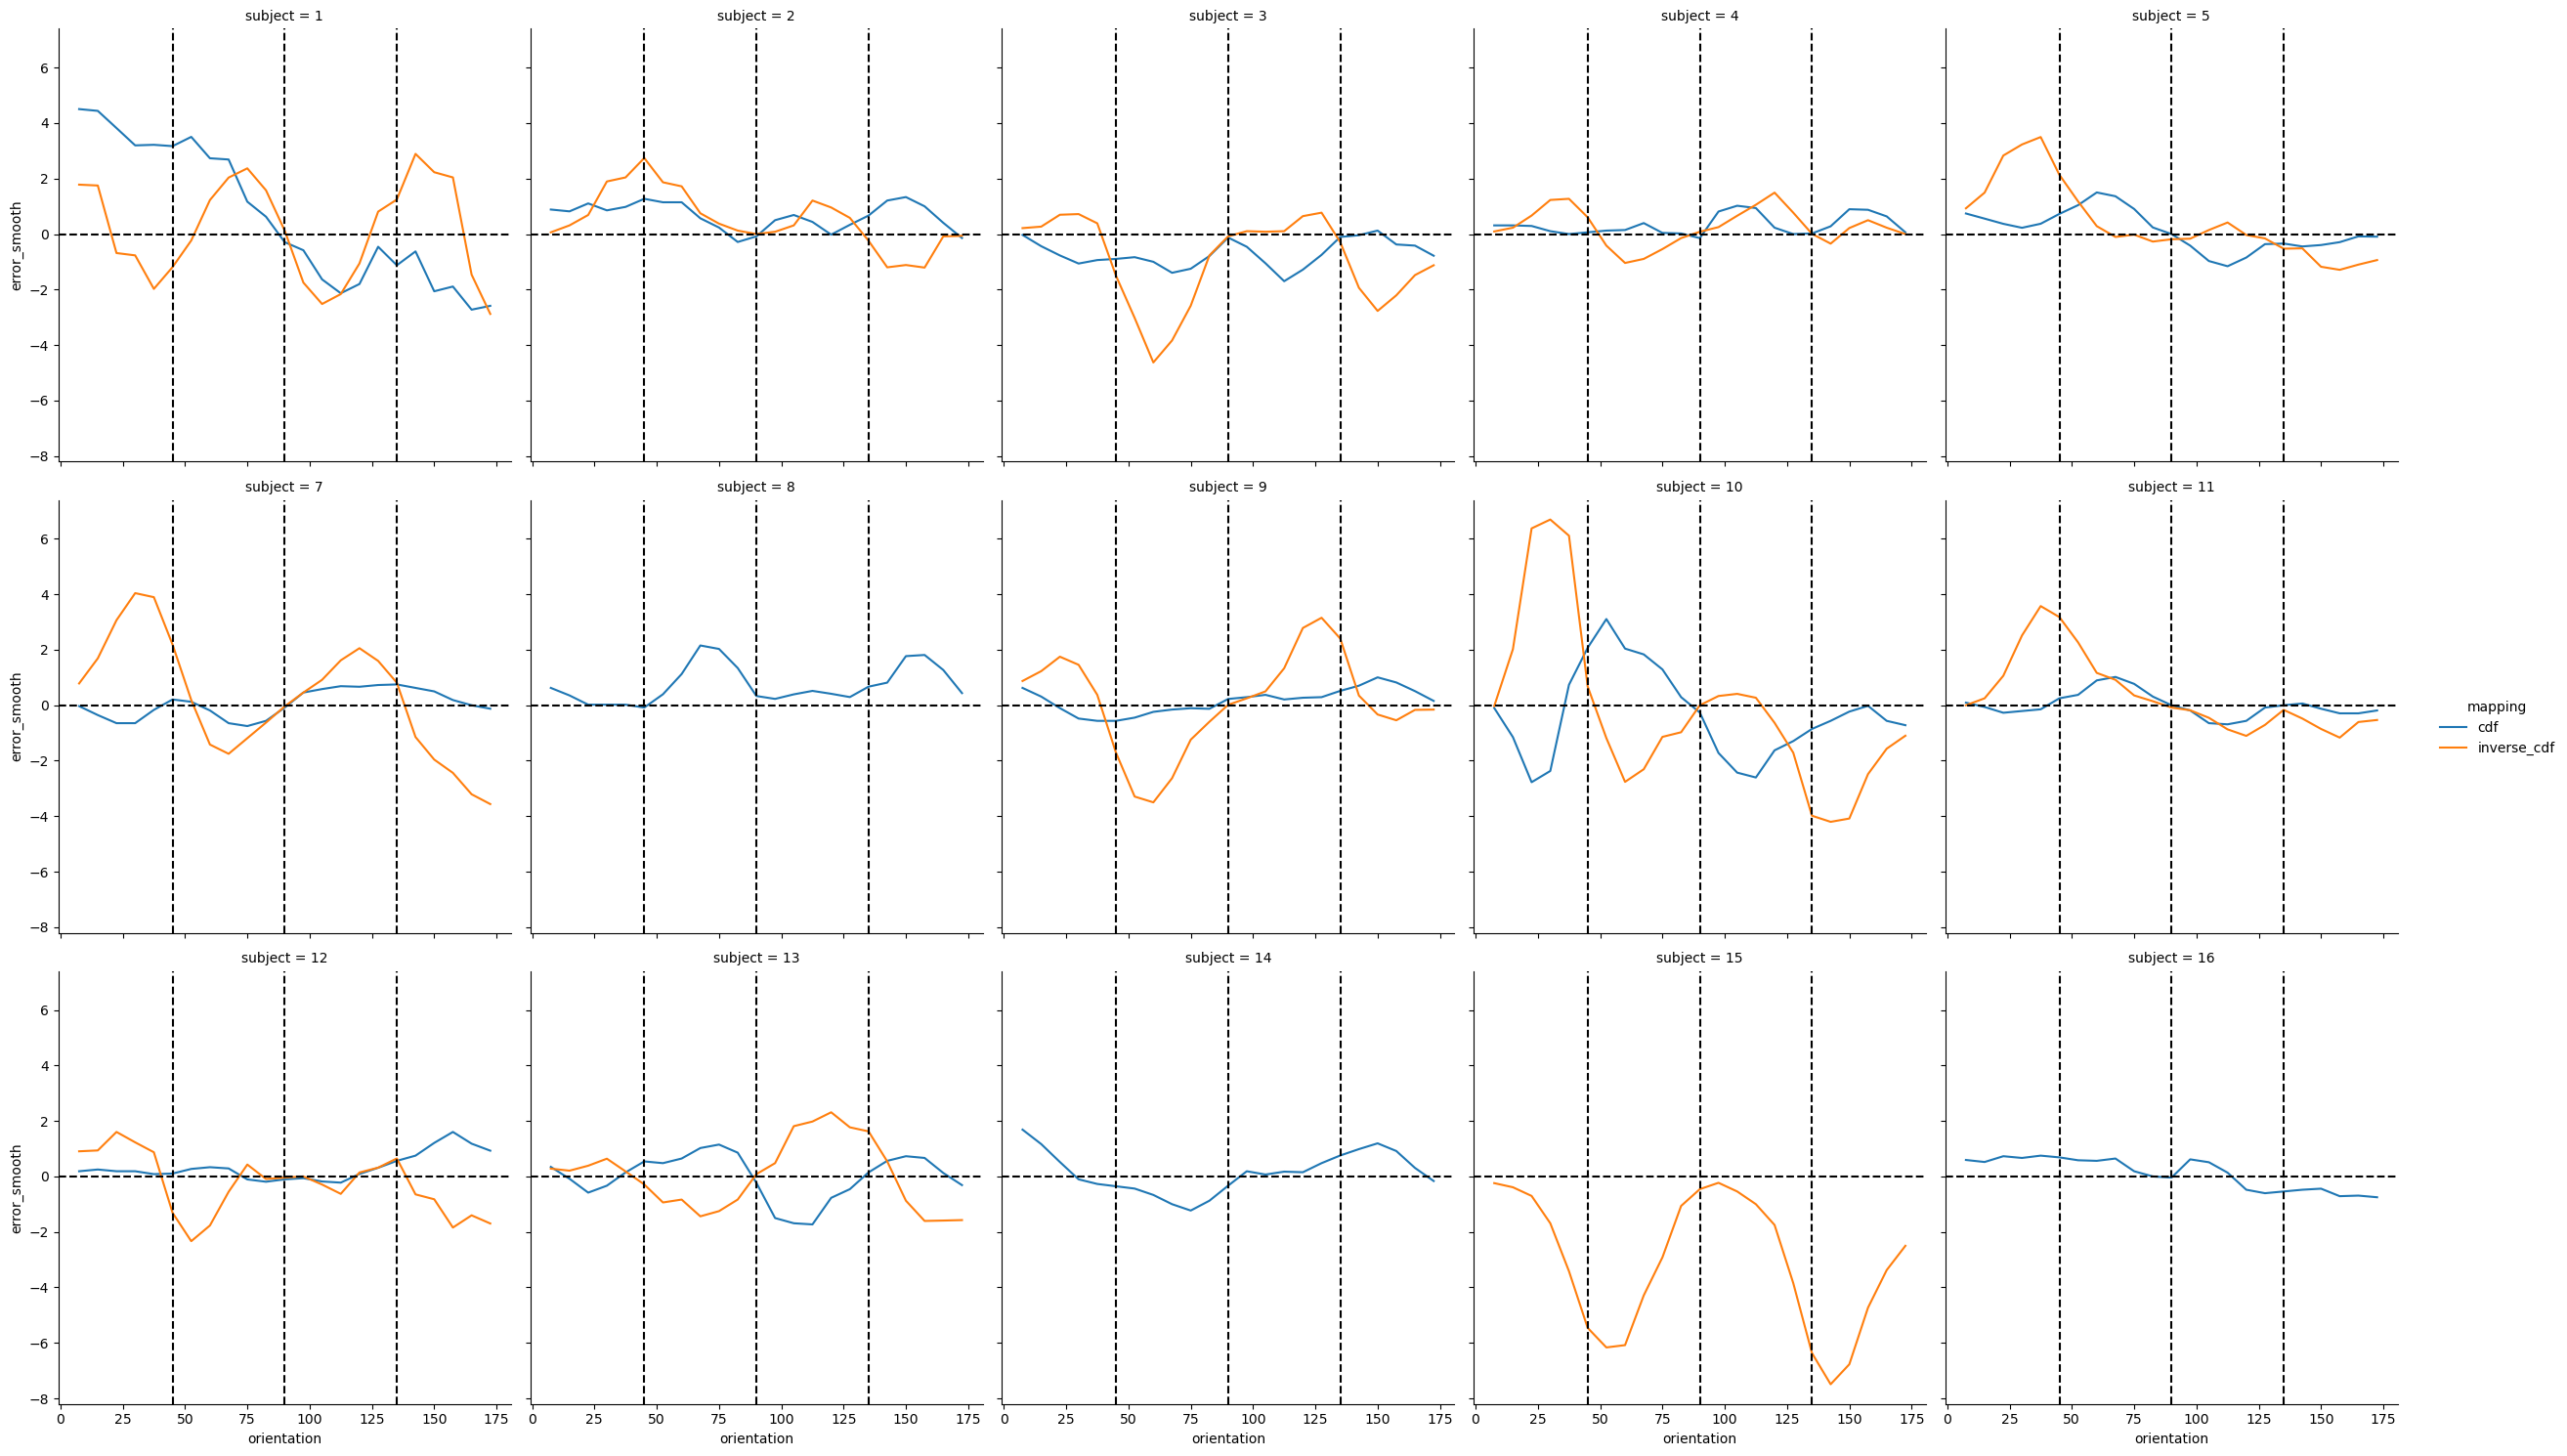

In [26]:
g = sns.relplot(data=tmp, x='orientation', y='error_smooth', hue='mapping', kind='line', errorbar='se',
                col='subject', col_wrap=5)
g.map(plt.axhline, y=0, color='k', linestyle='--')
for ori in [45, 90, 135]:
    g.map(plt.axvline, x=ori, color='k', linestyle='--')

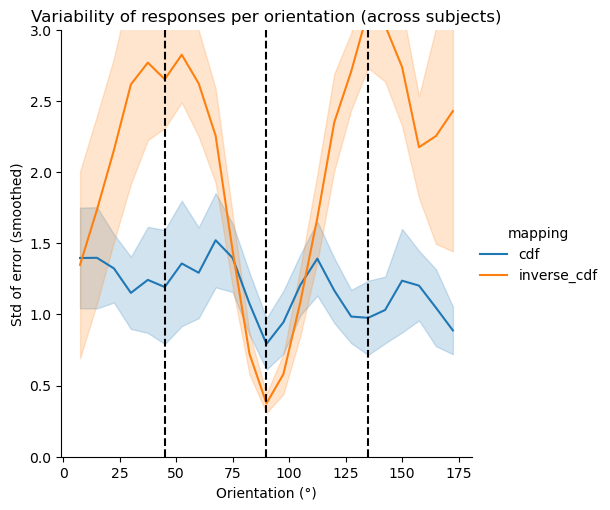

In [27]:
# Standard deviation of error per subject/mapping/orientation, smoothed over orientations
std_tmp = (
    work.groupby(['subject', 'mapping', 'orientation'], as_index=False)['error']
        .std()
        .rename(columns={'error': 'error_std'})
        .sort_values(['subject', 'mapping', 'orientation'])
)

std_tmp['error_std_smooth'] = (
    std_tmp.groupby(['subject', 'mapping'])['error_std']
           .transform(lambda s: s.rolling(3, center=True, min_periods=1).mean())
)

g = sns.relplot(data=std_tmp, x='orientation', y='error_std_smooth',
                hue='mapping', kind='line', errorbar='se')
g.set_axis_labels('Orientation (°)', 'Std of error (smoothed)')
plt.title('Variability of responses per orientation (across subjects)')

for ori in [45, 90, 135]:
    plt.axvline(ori, color='k', linestyle='--')

g.set(ylim=(0, 3))

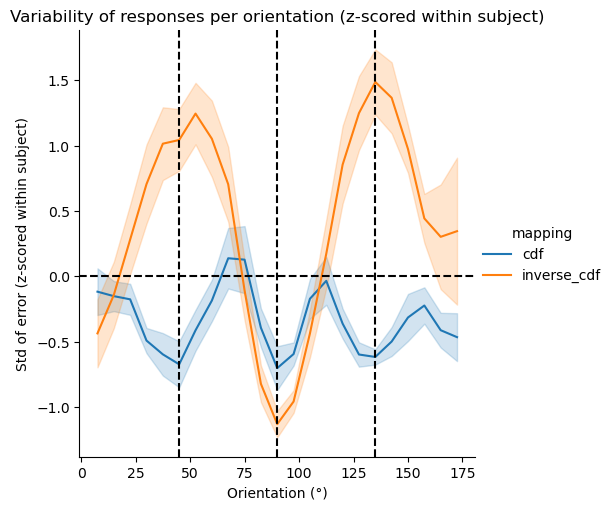

In [28]:
# Z-score error_std_smooth within each subject
std_tmp['error_std_z'] = (
    std_tmp.groupby('subject')['error_std_smooth']
           .transform(lambda s: (s - s.mean()) / s.std())
)

g = sns.relplot(data=std_tmp, x='orientation', y='error_std_z',
                hue='mapping', kind='line', errorbar='se')
g.set_axis_labels('Orientation (°)', 'Std of error (z-scored within subject)')
plt.title('Variability of responses per orientation (z-scored within subject)')
plt.axhline(0, color='k', linestyle='--')
for ori in [45, 90, 135]:
    plt.axvline(ori, color='k', linestyle='--')

In [29]:
rows = []
for subject_id in get_all_subject_ids():
    s = Subject(subject_id)
    try:
        d = s.get_behavioral_data().reset_index()
        d = d[d['event_type'] == 'feedback'].copy()
        d['response'] = pd.to_numeric(d['response'], errors='coerce')
        rows.append({
            'subject': subject_id,
            'n_rows': len(d),
            'n_response_nan': d['response'].isna().sum(),
            'mappings': sorted(d['mapping'].dropna().unique().tolist()),
            'runs_found': sorted(d['run'].dropna().unique().tolist()),
        })
    except Exception as e:
        rows.append({'subject': subject_id, 'error': str(e)})

pd.DataFrame(rows)

,subject,n_rows,n_response_nan,mappings,runs_found,error
0,1,368.0,17.0,"[cdf, inverse_cdf]","[1, 2, 3, 4, 5, 6, 7, 8]",NaN
1,10,368.0,17.0,"[cdf, inverse_cdf]","[1, 2, 3, 4, 5, 6, 7, 8]",NaN
2,11,368.0,5.0,"[cdf, inverse_cdf]","[1, 2, 3, 4, 5, 6, 7, 8]",NaN
3,12,368.0,16.0,"[cdf, inverse_cdf]","[1, 2, 3, 4, 5, 6, 7, 8]",NaN
4,13,368.0,5.0,"[cdf, inverse_cdf]","[1, 2, 3, 4, 5, 6, 7, 8]",NaN
5,14,184.0,6.0,[cdf],"[1, 2, 3, 4, 5, 6, 7, 8]",NaN
6,15,184.0,3.0,[inverse_cdf],"[1, 2, 3, 4, 5, 6, 7, 8]",NaN
7,16,184.0,3.0,[cdf],"[1, 2, 3, 4, 5, 6, 7, 8]",NaN
8,2,368.0,8.0,"[cdf, inverse_cdf]","[1, 2, 3, 4, 5, 6, 7, 8]",NaN
9,3,368.0,5.0,"[cdf, inverse_cdf]","[1, 2, 3, 4, 5, 6, 7, 8]",NaN


# Mean error per subject

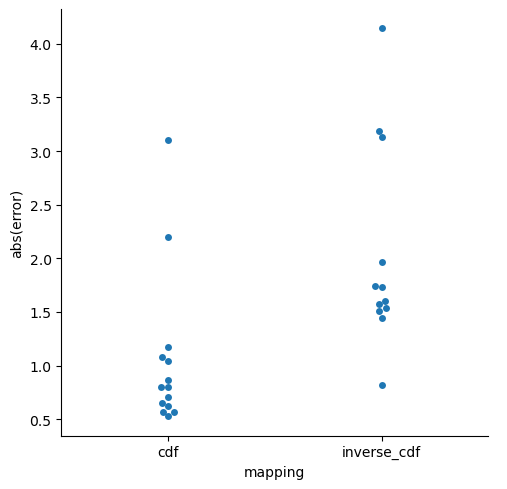

In [15]:
df['error'] = df['response'] - df['value']
df['abs(error)'] = df['error'].abs()
tmp = df.groupby(['subject', 'mapping'])['abs(error)'].mean()

sns.catplot(data=tmp.to_frame("abs(error)"), x='mapping', y='abs(error)', kind='swarm')


In [23]:
tmp.groupby('mapping').agg(['mean', 'std'])

,mean,std
mapping,,
cdf,1.245841,0.849379
inverse_cdf,1.952905,0.974780


In [19]:
tmp

subject  mapping    
1        cdf            3.103448
         inverse_cdf    4.144068
2        cdf            1.084270
         inverse_cdf    1.538462
3        cdf            0.797814
         inverse_cdf    1.602778
4        cdf            0.571429
         inverse_cdf    0.822222
5        cdf            0.654494
         inverse_cdf    1.505780
7        cdf            0.831522
         inverse_cdf    1.966667
8        cdf            1.171271
9        inverse_cdf    1.570225
10       cdf            2.200565
         inverse_cdf    3.189655
11       inverse_cdf    1.444751
12       cdf            0.797753
13       inverse_cdf    1.744444
Name: abs(error), dtype: float64

In [30]:
df

onset event_type  phase  \
subject session mapping     run trial_nr                                 
1       1       inverse_cdf 1   1         182.497262   feedback      5   
                                2         194.097588   feedback      5   
                                3         205.945464   feedback      5   
                                4         220.127548   feedback      5   
                                5         232.706319   feedback      5   
...                                              ...        ...    ...   
9       2       cdf         8   180       243.248386   feedback      5   
                                181       255.686161   feedback      5   
                                182       269.716201   feedback      5   
                                183       281.800095   feedback      5   
                                184       294.013650   feedback      5   

                                          response  nr_frames  orientation  \
subject session mapping     run trial_nr                                     
1       1       inverse_cdf 1   1             24.5       86.0         97.5   
                                2             39.5       86.0        150.0   
                                3             36.5       86.0        120.0   
                                4             36.5       86.0        127.5   
                                5             22.0       86.0         90.0   
...                                            ...        ...          ...   
9       2       cdf         8   180           11.0       85.0         30.0   
                                181           16.0       85.0         75.0   
                                182           11.5       85.0         37.5   
                                183           31.0       85.0        127.5   
                                184           30.0       85.0        112.5   

                                          value  reward  response_time  \
subject session mapping     run trial_nr                                 
1       1       inverse_cdf 1   1          25.5    42.0       2.688929   
                                2          33.0    42.5       2.275564   
                                3          31.0    50.5       2.098731   
                                4          31.5    49.5       2.770938   
                                5          22.0    42.0       2.334327   
...                                         ...     ...            ...   
9       2       cdf         8   180        11.0    43.0       1.864460   
                                181        16.0    51.5       1.780751   
                                182        11.5    42.0       2.795050   
                                183        31.5    55.5       1.863044   
                                184        30.0    69.0       2.051405   

                                           onset_abs  duration  
subject session mapping     run trial_nr                        
1       1       inverse_cdf 1   1         184.160455  1.013882  
                                2         195.760781  1.013845  
                                3         207.608657  1.013850  
                                4         221.790741  1.013867  
                                5         234.369512  1.013842  
...                                              ...       ...  
9       2       cdf         8   180       244.894860  1.002057  
                                181       257.332636  1.002091  
                                182       271.362676  1.002071  
                                183       283.446569  1.002051  
                                184       295.660124  1.002080  

[4784 rows x 11 columns]

,n,r,CI95%,p-val,power
spearman,11,0.509091,"[-0.13, 0.85]",0.109737,0.378607


,n,r,CI95%,p-val,BF10,power
pearson,11,0.946361,"[0.8, 0.99]",0.00001,1535.867,0.999409


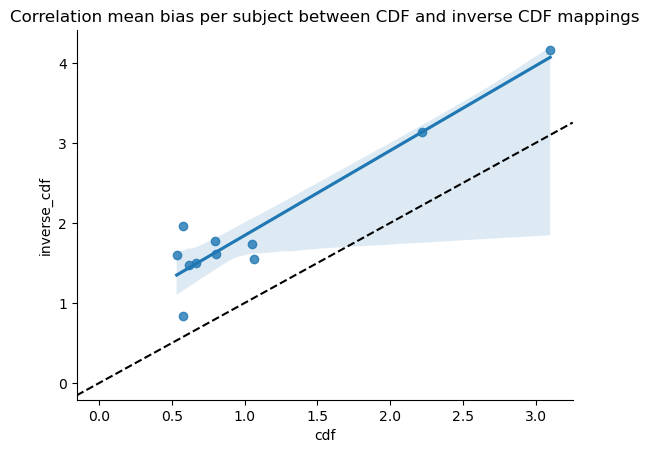

In [46]:
import pingouin as pg

df['error'] = df['response'] - df['value']
df['abs(error)'] = df['error'].abs()
mean_bias =  df.groupby(['subject', 'mapping', 'orientation'])['abs(error)'].mean().groupby(['subject', 'mapping']).mean()

tmp= mean_bias.unstack()

g = sns.regplot(data=tmp.reset_index(), x='cdf', y='inverse_cdf')
sns.despine()

g.set_title("Correlation mean bias per subject between CDF and inverse CDF mappings")
plt.axline((0,0), slope=1, color='k', linestyle='--')

display(pg.corr(tmp['cdf'], tmp['inverse_cdf'], method='spearman'))

display(pg.corr(tmp['cdf'], tmp['inverse_cdf'], method='pearson'))